In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("SuperStore_Sales_Dataset.csv")

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (5901, 23)

Columns:
Index(['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1',
       'ind2'],
      dtype='object')


In [4]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Row ID+O6G3A1:R6      int64
Order ID             object
Order Date           object
Ship Date            object
Ship Mode            object
Customer ID          object
Customer Name        object
Segment              object
Country              object
City                 object
State                object
Region               object
Product ID           object
Category             object
Sub-Category         object
Product Name         object
Sales               float64
Quantity              int64
Profit              float64
Returns             float64
Payment Mode         object
ind1                float64
ind2                float64
dtype: object


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
ind1                5901
ind2                5901
dtype: int64


In [6]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Row ID+O6G3A1:R6        Sales     Quantity       Profit  Returns  ind1  \
count       5901.000000  5901.000000  5901.000000  5901.000000    287.0   0.0   
mean        5022.422471   265.345589     3.781901    29.700408      1.0   NaN   
std         2877.977184   474.260645     2.212917   259.589138      0.0   NaN   
min            1.000000     0.836000     1.000000 -6599.978000      1.0   NaN   
25%         2486.000000    71.976000     2.000000     1.795500      1.0   NaN   
50%         5091.000000   128.648000     3.000000     8.502500      1.0   NaN   
75%         7456.000000   265.170000     5.000000    28.615000      1.0   NaN   
max         9994.000000  9099.930000    14.000000  8399.976000      1.0   NaN   

       ind2  
count   0.0  
mean    NaN  
std     NaN  
min     NaN  
25%     NaN  
50%     NaN  
75%     NaN  
max     NaN  


In [7]:
# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [8]:
# Remove unnecessary columns
df.drop(columns=["ind1", "ind2"], inplace=True)

In [9]:
# Fill missing return values
df["Returns"] = df["Returns"].fillna(0)

In [10]:
# Check duplicates
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [11]:
# Feature Engineering

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()

In [12]:
# Total Sales, Profit, Orders

print("\nTotal Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Orders:", df["Order ID"].nunique())


Total Sales: 1565804.32
Total Profit: 175262.11
Total Orders: 3003


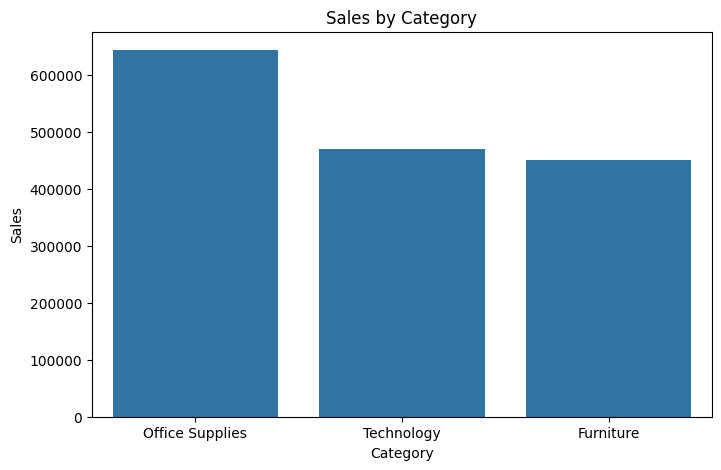

In [13]:
# SALES BY CATEGORY

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

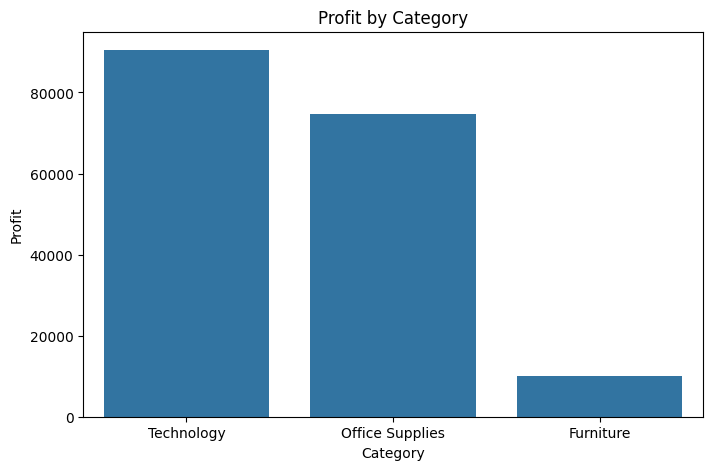

In [14]:
# PROFIT BY CATEGORY

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

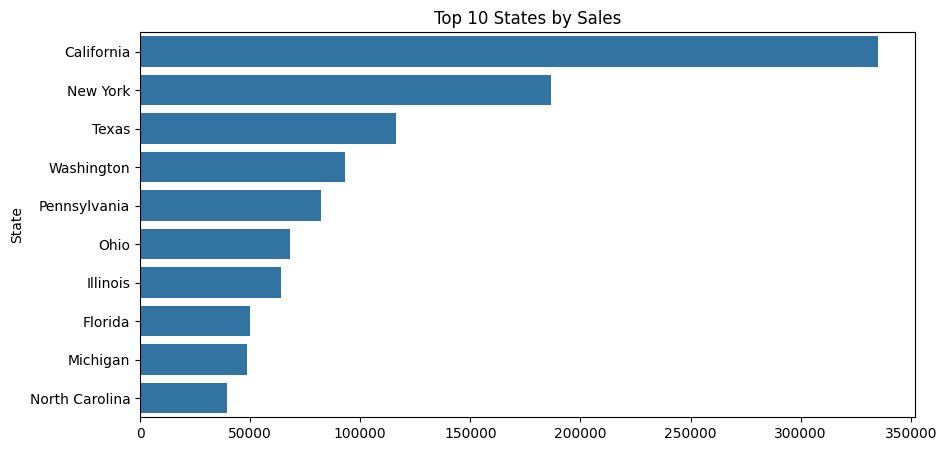

In [15]:
# TOP 10 STATES BY SALES

top_states = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_states.values,
    y=top_states.index
)
plt.title("Top 10 States by Sales")
plt.show()

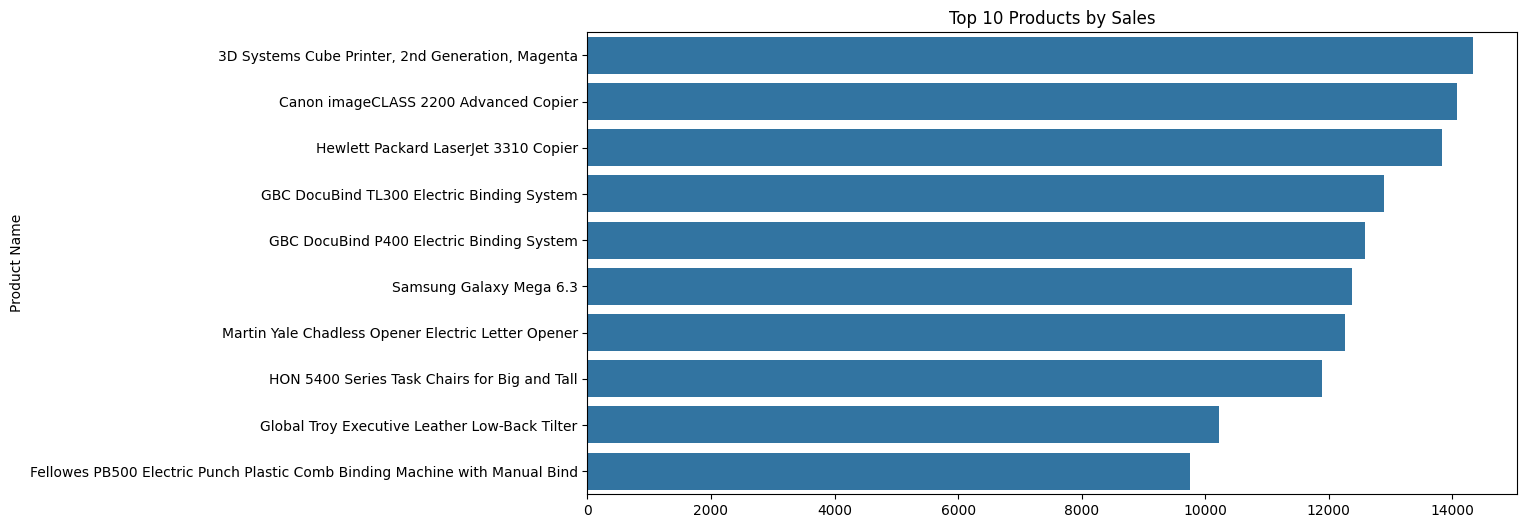

In [16]:
# TOP 10 PRODUCTS BY SALES

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index
)
plt.title("Top 10 Products by Sales")
plt.show()

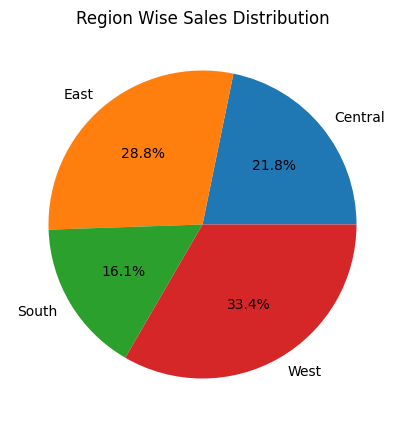

In [17]:
# SALES BY REGION

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))
region_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Region Wise Sales Distribution")
plt.ylabel("")
plt.show()

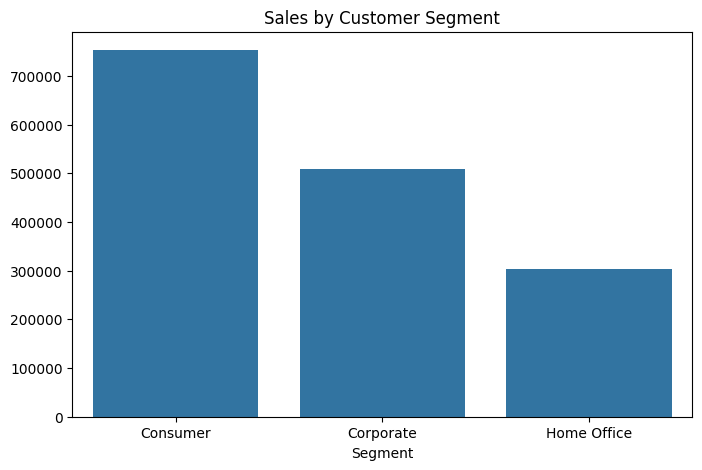

In [18]:
# SEGMENT ANALYSIS

segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)
plt.title("Sales by Customer Segment")
plt.show()

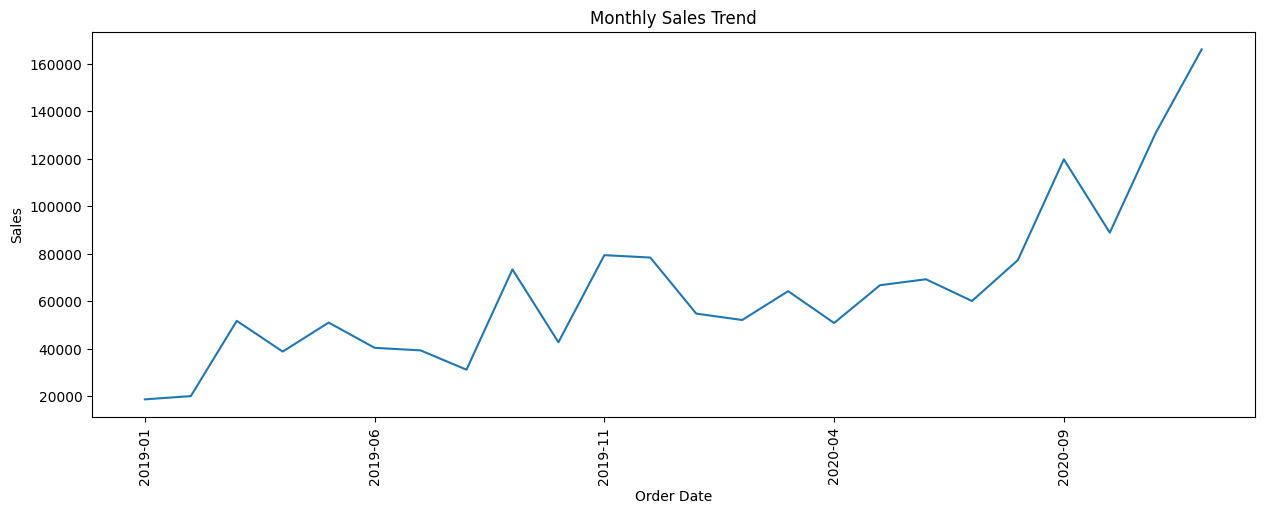

In [19]:
# MONTHLY SALES TREND

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(15,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()

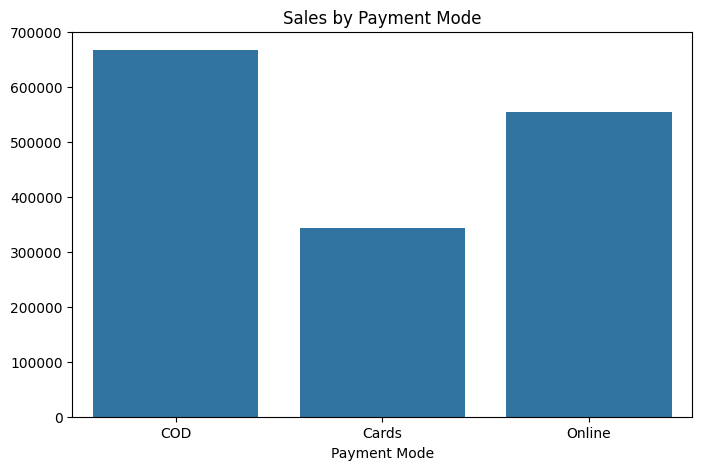

In [20]:
# PAYMENT MODE ANALYSIS

payment_sales = (
    df.groupby("Payment Mode")["Sales"]
    .sum()
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values
)
plt.title("Sales by Payment Mode")
plt.show()

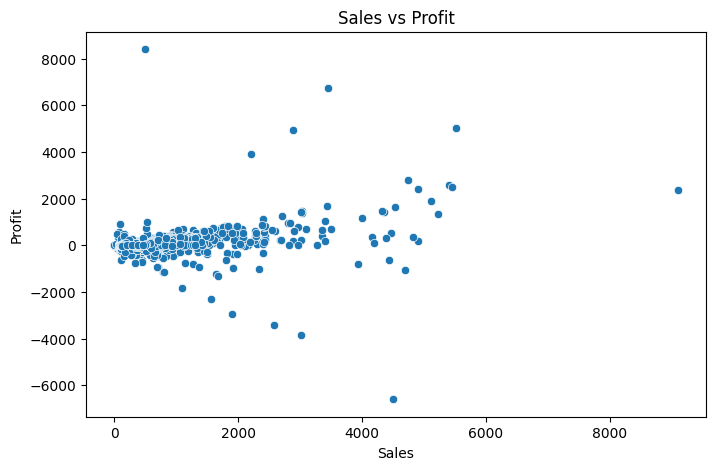

In [21]:
# PROFIT VS SALES

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit"
)
plt.title("Sales vs Profit")
plt.show()

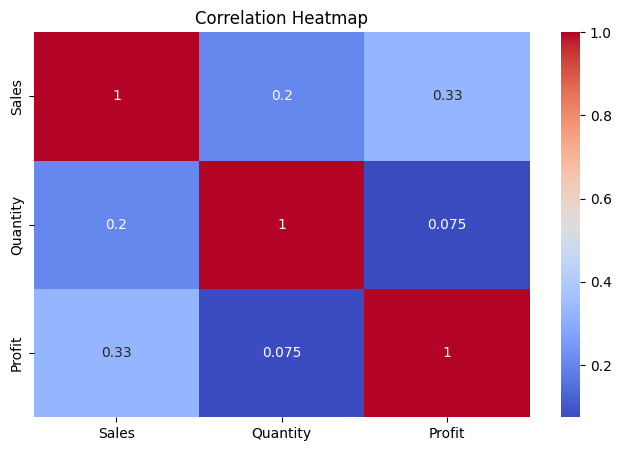

In [22]:
# CORRELATION HEATMAP

plt.figure(figsize=(8,5))
sns.heatmap(
    df[["Sales","Quantity","Profit"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [23]:
# RETURN ANALYSIS

print("\nTotal Returned Orders:",
      (df["Returns"] > 0).sum())

return_rate = (
    (df["Returns"] > 0).sum()
    / len(df)
) * 100

print("Return Rate:", round(return_rate,2), "%")


Total Returned Orders: 287
Return Rate: 4.86 %
